In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])



import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [3]:
# Open processed files
from open_data import *

data20 = processed_data_20cm
data30 = processed_data_30cm

In [4]:
freqs30 = list(data30.keys())
volts30 = []

for i in range(len(freqs30)):
    volts30.append(list(data30[freqs30[i]].keys()))

In [5]:
freqs20 = list(data20.keys())
volts20 = []

for i in range(len(freqs20)):
    volts20.append(list(data20[freqs20[i]].keys()))

In [6]:
k30 = []
for f in freqs30:
    k30.append(estimate_wavenumber(f, 0.3))

k20 = []
for f in freqs20:
    k20.append(estimate_wavenumber(f, 0.3))

In [7]:
results = []

def find_amps(data, f, v, condition, k, D):

    eta_r1 = data[f][v][condition]["R1"]
    eta_r2 = data[f][v][condition]["R2"]
    eta_r3 = data[f][v][condition]["R3"]

    # Getting the time series for each probe & run
    P0_r1, P0_r2, P0_r3 = eta_r1["P_0"], eta_r2["P_0"], eta_r3["P_0"]
    P1_r1, P1_r2, P1_r3 = eta_r1["P_1"], eta_r2["P_1"], eta_r3["P_1"]
    P2_r1, P2_r2, P2_r3 = eta_r1["P_2"], eta_r2["P_2"], eta_r3["P_2"]
    P3_r1, P3_r2, P3_r3 = eta_r1["P_3"], eta_r2["P_3"], eta_r3["P_3"]

    # Masks where data is not NaN (use P0 to define time)
    mask_P0_r1 = ~P0_r1.isna()
    mask_P0_r2 = ~P0_r2.isna()
    mask_P0_r3 = ~P0_r3.isna()

    # Masks for P1–P3
    mask_P1_r1 = ~P1_r1.isna()
    mask_P1_r2 = ~P1_r2.isna()
    mask_P1_r3 = ~P1_r3.isna()

    mask_P2_r1 = ~P2_r1.isna()
    mask_P2_r2 = ~P2_r2.isna()
    mask_P2_r3 = ~P2_r3.isna()

    mask_P3_r1 = ~P3_r1.isna()
    mask_P3_r2 = ~P3_r2.isna()
    mask_P3_r3 = ~P3_r3.isna()

    # Convert to numpy & sign flip
    P0_r1 = -P0_r1[mask_P0_r1].values
    P0_r2 = -P0_r2[mask_P0_r2].values
    P0_r3 = -P0_r3[mask_P0_r3].values

    P1_r1 = -P1_r1[mask_P1_r1].values
    P1_r2 = -P1_r2[mask_P1_r2].values
    P1_r3 = -P1_r3[mask_P1_r3].values

    P2_r1 = -P2_r1[mask_P2_r1].values
    P2_r2 = -P2_r2[mask_P2_r2].values
    P2_r3 = -P2_r3[mask_P2_r3].values

    P3_r1 = -P3_r1[mask_P3_r1].values
    P3_r2 = -P3_r2[mask_P3_r2].values
    P3_r3 = -P3_r3[mask_P3_r3].values

    # Find peaks
    distance = (1 / f) * 250 * 0.8  # 80% of the period in samples

    def peak_amp(x, std):
        idx = sc.signal.find_peaks(x, height=(0.9 * np.sqrt(2) * std, 1.2 * np.sqrt(2) * std), distance=distance)[0]
        peaks = x[idx]
        peaks = peaks[peaks > 0]

        mean_amp = np.mean(peaks)
        std_amp = np.std(peaks, ddof=1)   # sample standard deviation
        n = len(peaks)
        err_amp = std_amp / np.sqrt(n)    # standard error
        return mean_amp, err_amp

    # Compute mean amplitude and SE for each probe & run
    amp_P0_r1, se_P0_r1 = peak_amp(P0_r1, np.std(P0_r1))
    amp_P0_r2, se_P0_r2 = peak_amp(P0_r2, np.std(P0_r2))
    amp_P0_r3, se_P0_r3 = peak_amp(P0_r3, np.std(P0_r3))

    amp_P1_r1, se_P1_r1 = peak_amp(P1_r1, np.std(P1_r1))
    amp_P1_r2, se_P1_r2 = peak_amp(P1_r2, np.std(P1_r2))
    amp_P1_r3, se_P1_r3 = peak_amp(P1_r3, np.std(P1_r3))

    amp_P2_r1, se_P2_r1 = peak_amp(P2_r1, np.std(P2_r1))
    amp_P2_r2, se_P2_r2 = peak_amp(P2_r2, np.std(P2_r2))
    amp_P2_r3, se_P2_r3 = peak_amp(P2_r3, np.std(P2_r3))

    amp_P3_r1, se_P3_r1 = peak_amp(P3_r1, np.std(P3_r1))
    amp_P3_r2, se_P3_r2 = peak_amp(P3_r2, np.std(P3_r2))
    amp_P3_r3, se_P3_r3 = peak_amp(P3_r3, np.std(P3_r3))

    # Compute decay rate
    probe_pos = [4.86, 6.69, 7.87, 9.15]
    alpha_r1, se_alpha_r1 = get_obs_damping_coeff([amp_P0_r1, amp_P1_r1, amp_P2_r1, amp_P3_r1], probe_pos)
    alpha_r2, se_alpha_r2 = get_obs_damping_coeff([amp_P0_r2, amp_P1_r2, amp_P2_r2, amp_P3_r2], probe_pos)
    alpha_r3, se_alpha_r3 = get_obs_damping_coeff([amp_P0_r3, amp_P1_r3, amp_P2_r3, amp_P3_r3], probe_pos)

    # Collect per-run rows
    runs = ["R1", "R2", "R3"]
    amps = [
        (amp_P0_r1, amp_P1_r1, amp_P2_r1, amp_P3_r1,
         se_P0_r1,  se_P1_r1,  se_P2_r1,  se_P3_r1),
        (amp_P0_r2, amp_P1_r2, amp_P2_r2, amp_P3_r2,
         se_P0_r2,  se_P1_r2,  se_P2_r2,  se_P3_r2),
        (amp_P0_r3, amp_P1_r3, amp_P2_r3, amp_P3_r3,
         se_P0_r3,  se_P1_r3,  se_P2_r3,  se_P3_r3),
    ]
    alpha = [alpha_r1, alpha_r2, alpha_r3]
    se_alpha = [se_alpha_r1, se_alpha_r2, se_alpha_r3]

    if D == 0.3:
        if v < 0.2:
            v_tag = 'low'
        if v >= 0.2 and v < 0.305:
            v_tag = 'medium'
        if v >= 0.370 and v < 0.385:
            v_tag = 'medium-high'
        if v >= 0.4:
            v_tag = 'high'

    else:
        if v == 0.1:
            v_tag = 'low'
        if v == 0.2:
            v_tag = 'medium'
        if v == 0.25:
            v_tag = 'medium-high'
        if v == 0.3:
            v_tag = 'high'
        
    for run, (a0, a1, a2, a3, e0, e1, e2, e3) in zip(runs, amps):
        results.append({
            "frequency": f,
            "volt": v,
            "volt_level": v_tag,
            "condition": condition,
            "run": run,
            "ak": a0 * k,
            "kH": k*D,
            "amp_P0": a0,
            "amp_P1": a1,
            "amp_P2": a2,
            "amp_P3": a3,
            "se_P0": e0,
            "se_P1": e1,
            "se_P2": e2,
            "se_P3": e3,
            "alpha": alpha[runs.index(run)],
            "se_alpha": se_alpha[runs.index(run)],
        })


def process_condition(data, f, v, condition, k, D):
    find_amps(data, f, v, condition, k, D)

for i, f in enumerate(freqs20):
    k = estimate_wavenumber(f, 0.2)
    for v in volts20[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data20, f, v, condition="p005", k=k, D=0.2)
        process_condition(data20, f, v, condition="None", k=k, D=0.2)

df_20 = pd.DataFrame(results)

Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Frequency: 1.8, Voltage: 0.1
Frequency: 1.8, Voltage: 0.2
Frequency: 1.8, Voltage: 0.25
Frequency: 1.8, Voltage: 0.3


In [8]:
results = []
for i, f in enumerate(freqs30):
    k = estimate_wavenumber(f, 0.3)
    for v in volts30[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data30, f, v, condition="p005", k=k, D=0.3)
        process_condition(data30, f, v, condition="None", k=k, D=0.3)

df_30 = pd.DataFrame(results)

Frequency: 0.898, Voltage: 0.149


Frequency: 0.898, Voltage: 0.299
Frequency: 0.898, Voltage: 0.453
Frequency: 0.98, Voltage: 0.149
Frequency: 0.98, Voltage: 0.295
Frequency: 0.98, Voltage: 0.443
Frequency: 1.061, Voltage: 0.149
Frequency: 1.061, Voltage: 0.295
Frequency: 1.061, Voltage: 0.449
Frequency: 1.143, Voltage: 0.148
Frequency: 1.143, Voltage: 0.295
Frequency: 1.143, Voltage: 0.443
Frequency: 1.225, Voltage: 0.152
Frequency: 1.225, Voltage: 0.299
Frequency: 1.225, Voltage: 0.471
Frequency: 1.306, Voltage: 0.152
Frequency: 1.306, Voltage: 0.302
Frequency: 1.306, Voltage: 0.372
Frequency: 1.306, Voltage: 0.461
Frequency: 1.388, Voltage: 0.147
Frequency: 1.388, Voltage: 0.285
Frequency: 1.388, Voltage: 0.378
Frequency: 1.388, Voltage: 0.468
Frequency: 1.47, Voltage: 0.147
Frequency: 1.47, Voltage: 0.296
Frequency: 1.47, Voltage: 0.382
Frequency: 1.47, Voltage: 0.459


In [9]:
df_30

,frequency,volt,volt_level,condition,run,ak,kH,amp_P0,amp_P1,amp_P2,amp_P3,se_P0,se_P1,se_P2,se_P3,alpha,se_alpha
0,0.898,0.149,low,p005,R1,0.029146,1.177642,0.007425,0.007541,0.007239,0.006901,0.000043,0.000047,0.000094,0.000108,0.017285,0.008781
1,0.898,0.149,low,p005,R2,0.029286,1.177642,0.007460,0.007548,0.007250,0.006988,0.000038,0.000041,0.000074,0.000115,0.015772,0.007263
2,0.898,0.149,low,p005,R3,0.029401,1.177642,0.007490,0.007515,0.007266,0.006897,0.000027,0.000047,0.000062,0.000109,0.018971,0.007606
3,0.898,0.149,low,None,R1,0.028450,1.177642,0.007248,0.007411,0.007275,0.007242,0.000047,0.000054,0.000055,0.000087,0.000879,0.004142
4,0.898,0.149,low,None,R2,0.028482,1.177642,0.007256,0.007499,0.007174,0.007290,0.000038,0.000051,0.000068,0.000067,0.001367,0.007246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,1.470,0.459,high,p005,R2,0.329883,2.635770,0.037547,0.038476,0.039494,0.034014,0.000367,0.000298,0.000551,0.000686,0.017313,0.022151
158,1.470,0.459,high,p005,R3,0.337971,2.635770,0.038467,0.036873,0.039433,0.034565,0.000386,0.000390,0.000454,0.000555,0.017803,0.018484
159,1.470,0.459,high,None,R1,0.342234,2.635770,0.038953,0.039025,0.039256,0.039072,0.000103,0.000194,0.000359,0.000295,-0.001098,0.001021
160,1.470,0.459,high,None,R2,0.337705,2.635770,0.038437,0.038735,0.039462,0.038119,0.000276,0.000242,0.000237,0.000164,0.000105,0.005732


In [10]:
no_plates_20 = df_20[df_20["condition"]=="None"]
plates_20 = df_20[df_20["condition"] == "p005"]

no_plates_30 = df_30[df_30["condition"]=="None"]
plates_30 = df_30[df_30["condition"] == "p005"]

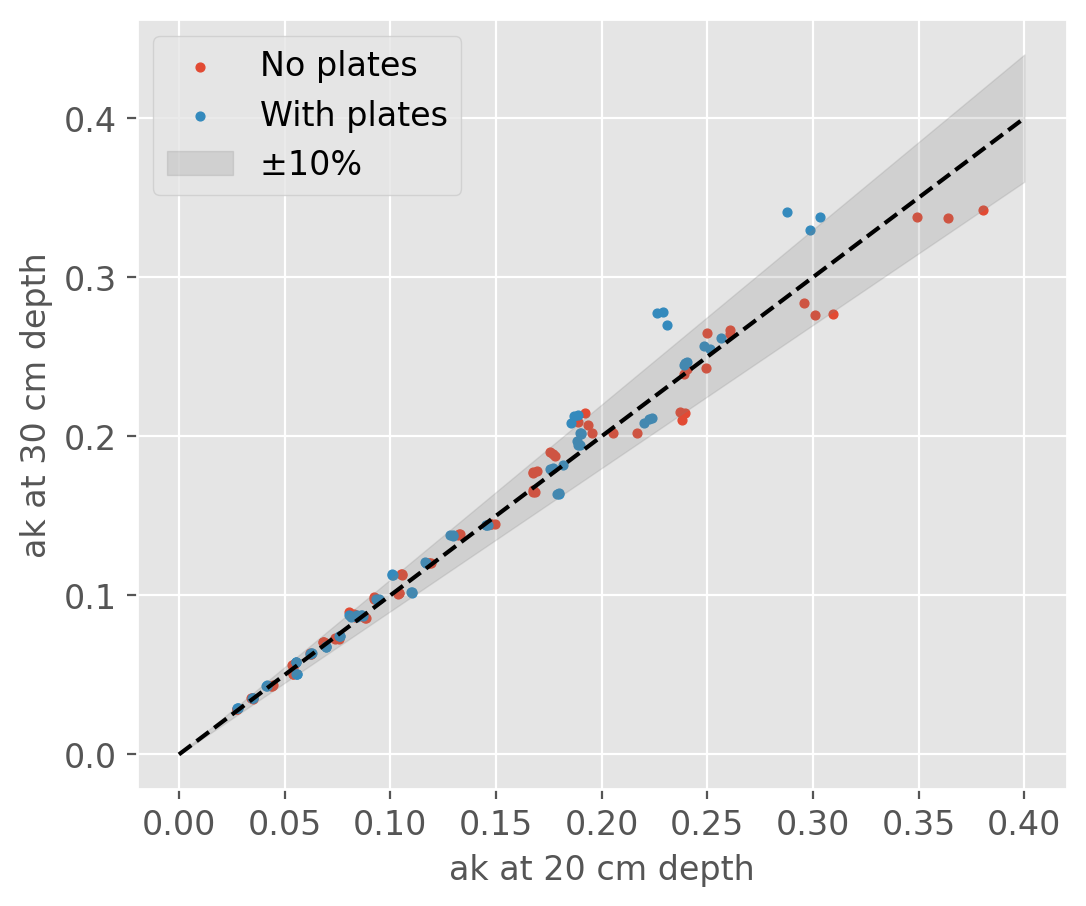

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(no_plates_20['ak'], no_plates_30['ak'], s=10, label='No plates')
ax.scatter(plates_20['ak'], plates_30['ak'], s=10, label='With plates')
ax.set_xlabel('ak at 20 cm depth')
ax.set_ylabel('ak at 30 cm depth')

mx = 0.4
# 1:1 line
x = np.linspace(0, mx, 200)
y = x
ax.plot(x, y, 'k--')

# ±10% band around 1:1 line
upper = y * 1.1
lower = y * 0.9
ax.fill_between(x, lower, upper, color='gray', alpha=0.2, label='±10% ')

ax.legend()

# Amplitude profiles

In [12]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [13]:
no_plates_20[(no_plates_20["frequency"] == 1.1) & (no_plates_20["volt_level"] == "low")]

,frequency,volt,volt_level,condition,run,ak,kH,amp_P0,amp_P1,amp_P2,amp_P3,se_P0,se_P1,se_P2,se_P3,alpha,se_alpha
3,1.1,0.1,low,None,R1,0.027515,1.177906,0.004672,0.004504,0.004536,0.004363,0.000020,0.000023,0.000040,0.000022,0.014273,0.004108
4,1.1,0.1,low,None,R2,0.027491,1.177906,0.004668,0.004497,0.004517,0.004432,0.000021,0.000027,0.000036,0.000011,0.011142,0.003170
5,1.1,0.1,low,None,R3,0.027532,1.177906,0.004675,0.004537,0.004471,0.004524,0.000031,0.000028,0.000035,0.000045,0.008476,0.004238


In [14]:
no_plates_30[(no_plates_30["frequency"] == 0.898) & (no_plates_30["volt_level"] == "high")]

,frequency,volt,volt_level,condition,run,ak,kH,amp_P0,amp_P1,amp_P2,amp_P3,se_P0,se_P1,se_P2,se_P3,alpha,se_alpha
15,0.898,0.453,high,None,R1,0.086104,1.177642,0.021935,0.022316,0.022226,0.022226,0.000083,0.000151,0.000173,0.000189,-0.002838,0.002111
16,0.898,0.453,high,None,R2,0.085991,1.177642,0.021906,0.022457,0.022288,0.022206,0.000099,0.000164,0.000180,0.000196,-0.002869,0.003487
17,0.898,0.453,high,None,R3,0.085815,1.177642,0.021861,0.022448,0.022340,0.022190,0.000092,0.000163,0.000185,0.000212,-0.003381,0.003784


In [18]:
def plot_amplitudes_along_tank(df_no, df_with, f, volt_level, D):
    # Filter by frequency and voltage
    df_subset_no = df_no[(df_no["frequency"] == f) & (df_no["volt_level"] == volt_level)]
    df_subset_with = df_with[(df_with["frequency"] == f) & (df_with["volt_level"] == volt_level)]

    volt = df_subset_no["volt"].iloc[0]  # Get the actual voltage value for the title

    # Extract the row for each run 
    r1_no = df_subset_no[df_subset_no["run"] == "R1"].iloc[0]
    r2_no = df_subset_no[df_subset_no["run"] == "R2"].iloc[0]
    r3_no = df_subset_no[df_subset_no["run"] == "R3"].iloc[0]

    r1_with = df_subset_with[df_subset_with["run"] == "R1"].iloc[0]
    r2_with = df_subset_with[df_subset_with["run"] == "R2"].iloc[0]
    r3_with = df_subset_with[df_subset_with["run"] == "R3"].iloc[0]


    # Build 1D arrays of amplitudes in probe order P0–P3
    r1_amps_no = np.array([r1_no["amp_P0"], r1_no["amp_P1"], r1_no["amp_P2"], r1_no["amp_P3"]])
    r2_amps_no = np.array([r2_no["amp_P0"], r2_no["amp_P1"], r2_no["amp_P2"], r2_no["amp_P3"]])
    r3_amps_no = np.array([r3_no["amp_P0"], r3_no["amp_P1"], r3_no["amp_P2"], r3_no["amp_P3"]])

    r1_amps_with = np.array([r1_with["amp_P0"], r1_with["amp_P1"], r1_with["amp_P2"], r1_with["amp_P3"]])
    r2_amps_with = np.array([r2_with["amp_P0"], r2_with["amp_P1"], r2_with["amp_P2"], r2_with["amp_P3"]])
    r3_amps_with = np.array([r3_with["amp_P0"], r3_with["amp_P1"], r3_with["amp_P2"], r3_with["amp_P3"]])

    # Exponential decay profile
    mean_p0_no = np.mean([r1_no["amp_P0"], r2_no["amp_P0"], r3_no["amp_P0"]])
    mean_p0_with = np.mean([r1_with["amp_P0"], r2_with["amp_P0"], r3_with["amp_P0"]])

    alpha_no = np.mean([r1_no["alpha"], r2_no["alpha"], r3_no["alpha"]]) 
    alpha_with = np.mean([r1_with["alpha"], r2_with["alpha"], r3_with["alpha"]])

    exp_prof_no = mean_p0_no * np.exp(-x_prof * alpha_no)
    exp_prof_with = mean_p0_with * np.exp(-x_prof * alpha_with)

    # Corresponding standard errors
    r1_se_no = np.array([r1_no["se_P0"], r1_no["se_P1"], r1_no["se_P2"], r1_no["se_P3"]])
    r2_se_no = np.array([r2_no["se_P0"], r2_no["se_P1"], r2_no["se_P2"], r2_no["se_P3"]])
    r3_se_no = np.array([r3_no["se_P0"], r3_no["se_P1"], r3_no["se_P2"], r3_no["se_P3"]])

    r1_se_with = np.array([r1_with["se_P0"], r1_with["se_P1"], r1_with["se_P2"], r1_with["se_P3"]])
    r2_se_with = np.array([r2_with["se_P0"], r2_with["se_P1"], r2_with["se_P2"], r2_with["se_P3"]])
    r3_se_with = np.array([r3_with["se_P0"], r3_with["se_P1"], r3_with["se_P2"], r3_with["se_P3"]])

    # Plot the profile of amplitudes along the tank for both conditions
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    err_kwargs = dict(
        ecolor="grey",     
        elinewidth=1.0,   
        capsize=4,       
        capthick=1.0,       
    )

    ax[0].errorbar(x_probe_pos, r1_amps_no, color= 'C0', yerr=r1_se_no, fmt='o', **err_kwargs)
    ax[0].errorbar(x_probe_pos, r2_amps_no, color= 'C0', yerr=r2_se_no, fmt='o', **err_kwargs)
    ax[0].errorbar(x_probe_pos, r3_amps_no, color= 'C0', yerr=r3_se_no, fmt='o', **err_kwargs)

    ax[0].plot(x_probe_pos, exp_prof_no, 'k--', label=rf'$\alpha={-alpha_no:.4f}$')

    ax[0].set_xlabel('Distance from wave maker [m]')
    ax[0].set_ylabel('Amplitude [m]')
    ax[0].set_title(f'Without plates')
    ax[0].legend()

    ax[1].errorbar(x_probe_pos, r1_amps_with, color= 'C1', yerr=r1_se_with, fmt='o', **err_kwargs)
    ax[1].errorbar(x_probe_pos, r2_amps_with, color= 'C1', yerr=r2_se_with, fmt='o', **err_kwargs)
    ax[1].errorbar(x_probe_pos, r3_amps_with, color= 'C1', yerr=r3_se_with, fmt='o', **err_kwargs)

    ax[1].plot(x_probe_pos, exp_prof_with, 'k--', label=rf'$\alpha={-alpha_with:.4f}$')

    ax[1].set_xlabel('Distance from wave maker [m]')
    ax[1].set_ylabel('Amplitude [m]')
    ax[1].set_title(f'With plates')
    ax[1].legend()
    fig.suptitle(f'f={f} Hz, A={volt} V, D = {D} m')
    plt.tight_layout()
    plt.show()

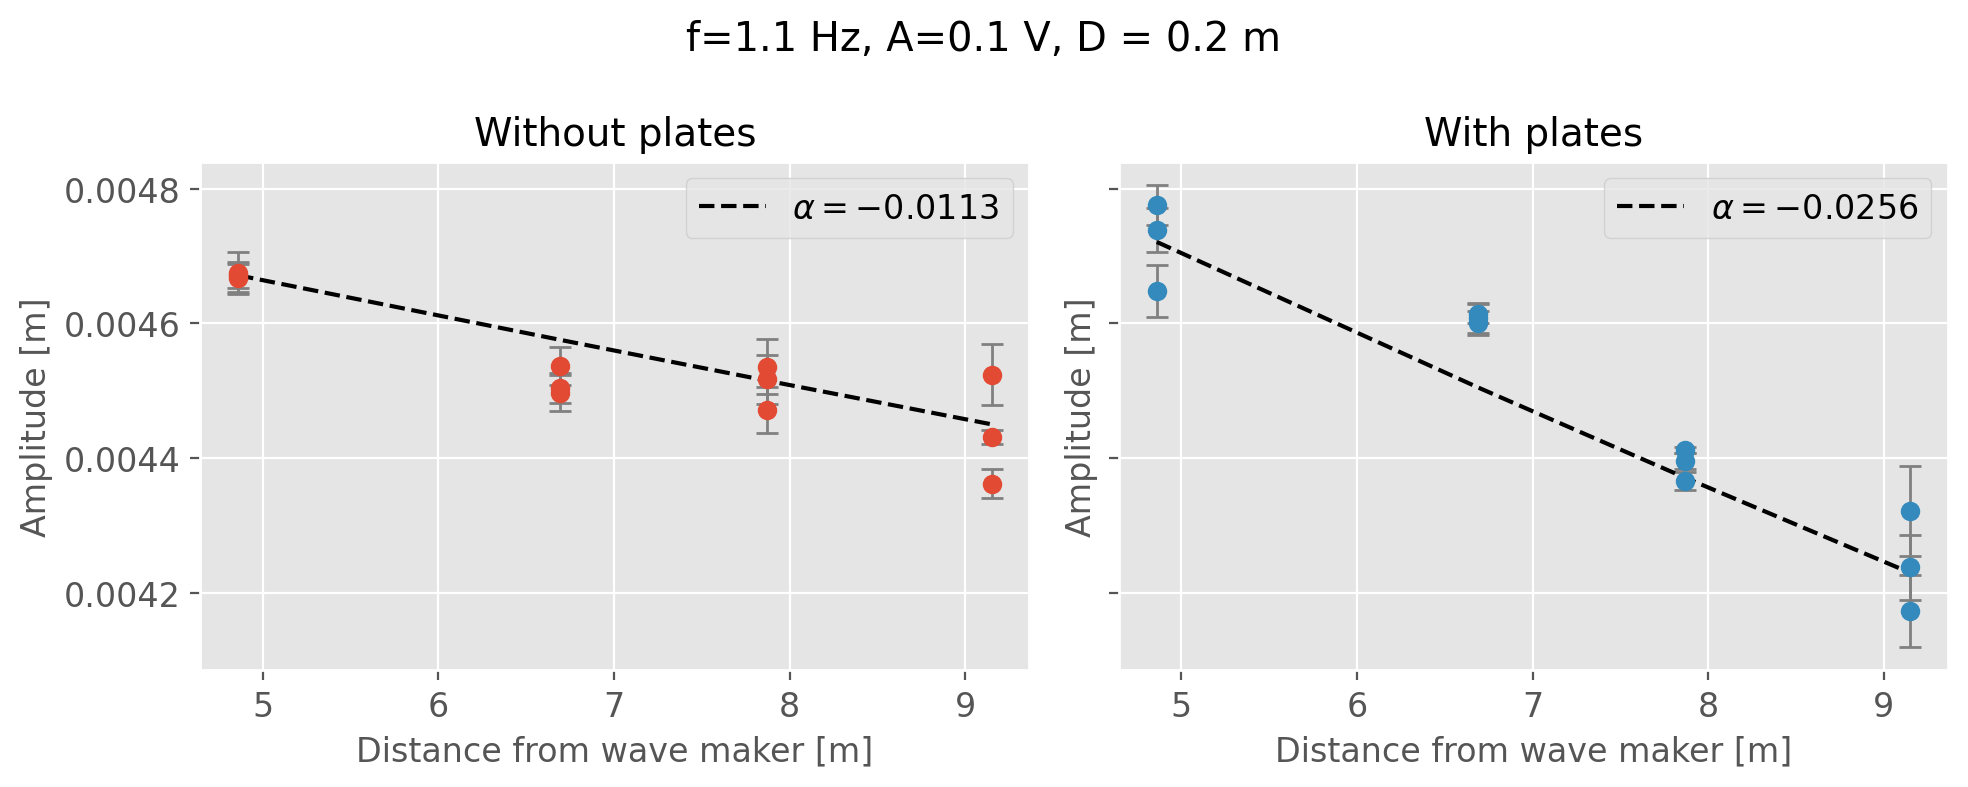

In [19]:
plot_amplitudes_along_tank(no_plates_20, plates_20, f=1.1, volt_level="low", D=0.2)

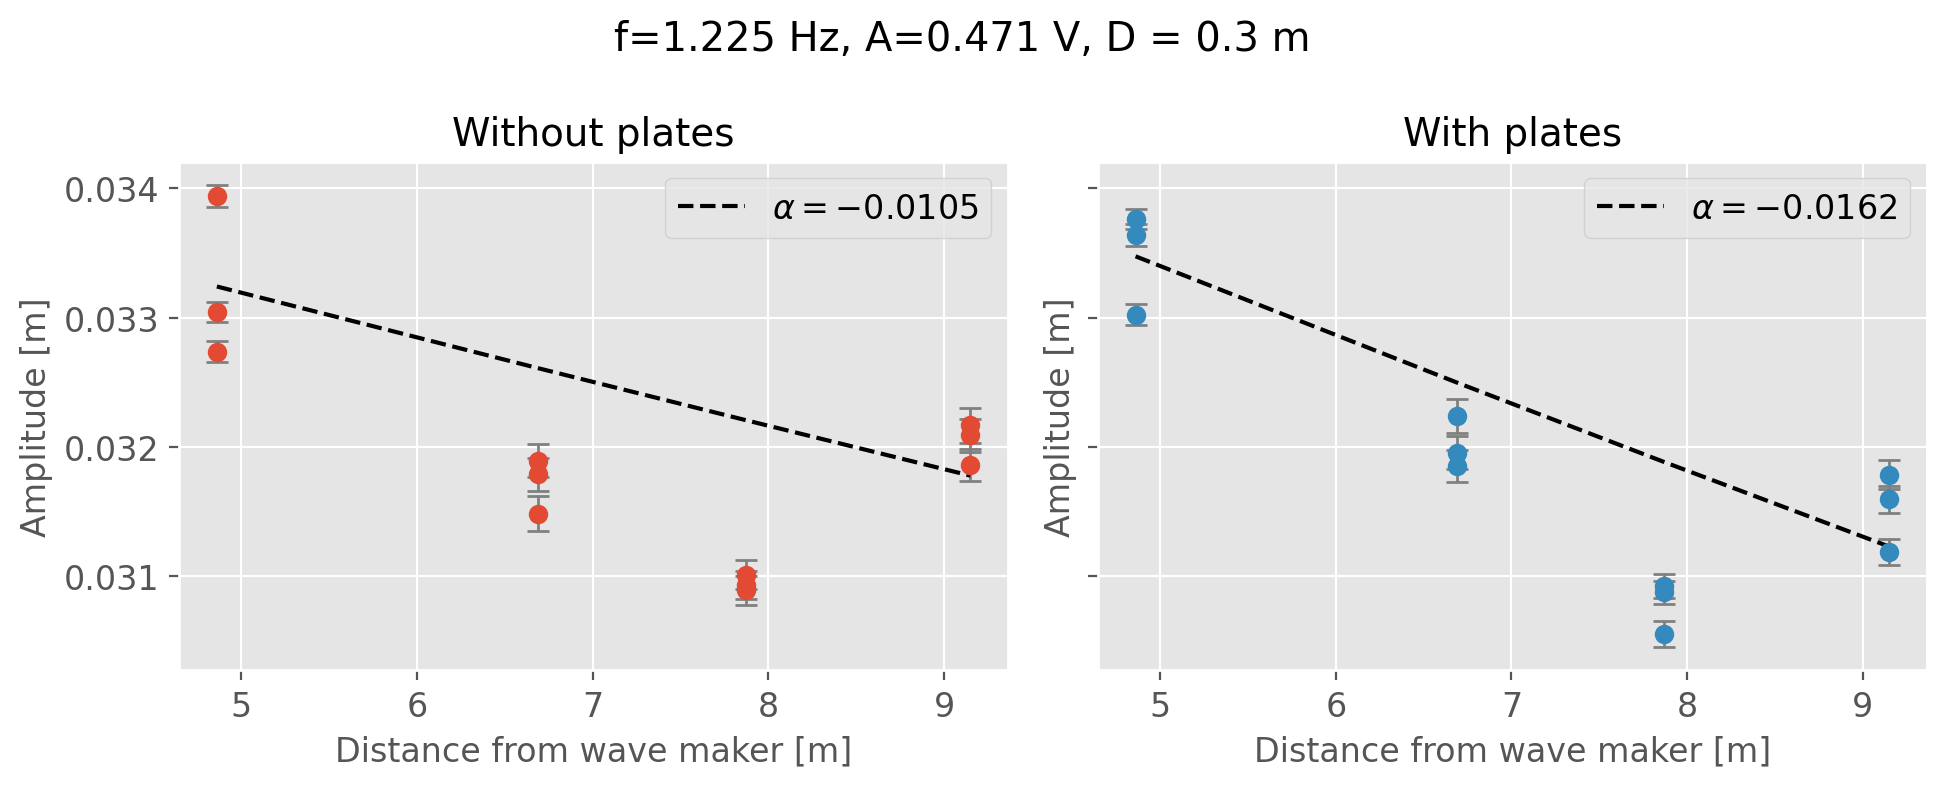

In [22]:
plot_amplitudes_along_tank(no_plates_30, plates_30, f=1.225, volt_level="high", D=0.3)